# ForceSMIP Challenge Analysis - Refactored

This notebook demonstrates the ForceSMIP analysis using the new encapsulated modules.

## 1. Setup and Imports

In [1]:
import sys
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# Add src to path
sys.path.append(os.path.join(os.getcwd(), "src"))

# Import our modules
from data_loader import ForceSMIPDataLoader, yearly_average, compute_yearly_average_dict
from preprocessing import (
    merge_training_data, reshape_training_data, 
    moving_average_smoothing, exponential_smoothing, gaussian_smoothing
)
from algorithms import WeightedRidgeRegression, ridge_regression, low_rank_approximation, LowRankSolver
from evaluation import ForceSMIPEvaluator, compute_trends_from_data, compute_statistics
from visualization import ForceSMIPVisualizer
from forcesmip_pipeline import ForceSMIPPipeline

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Modules loaded successfully!")

Modules loaded successfully!


## 2. Quick Start - Complete Pipeline

In [2]:
# Initialize pipeline
base_path = '/net/krypton/climdyn_nobackup/FTP'
variable = 'tas'  # Surface air temperature

pipeline = ForceSMIPPipeline(base_path, variable=variable)
print(f"Pipeline initialized for variable: {variable}")

Pipeline initialized for variable: tas


In [3]:
# # Run complete analysis with default parameters
# summary = pipeline.run_complete_analysis(
#     lambda_reg=2500.0,     # Ridge regression regularization
#     rank=10,               # Low-rank approximation rank
#     apply_smoothing=False  # Whether to apply temporal smoothing
# )

# print("\n=== Analysis Complete! ===")

In [4]:
# # Display performance summary
# print("\n=== Performance Summary ===")
# for method, metrics in summary.items():
#     print(f"\n{method}:")
#     print(f"  Mean NRMSE: {metrics['mean_nrmse']:.4f}")
#     print(f"  Mean Pattern Correlation: {metrics['mean_pattern_corr']:.4f}")
#     print(f"  Worst NRMSE: {metrics['worst_nrmse']:.4f}")

## 3. Step-by-Step Analysis (Manual Pipeline)

### 3.1 Data Loading

In [5]:
# Initialize data loader
data_loader = ForceSMIPDataLoader(base_path)

# Load training data
print("Loading training data...")
dic_data, dic_forced_response, longitude, latitude = data_loader.load_training_data(variable)

print(f"Training data loaded:")
print(f"  Number of models: {len(dic_data)}")
print(f"  Model names: {list(dic_data.keys())}")
print(f"  Grid shape: {latitude.shape[0]} x {longitude.shape[0]}")
print(f"  Time steps: {list(dic_data.values())[0].shape[1]}")

Loading training data...
Processing 1/5: CESM2
  Processing 1/50: tas_mon_CESM2_historical_ssp370_r1251.013i1p1f1.188001-210012.nc
  Processing 2/50: tas_mon_CESM2_historical_ssp370_r1011.001i1p1f1.188001-210012.nc
  Processing 3/50: tas_mon_CESM2_historical_ssp370_r1251.015i1p1f1.188001-210012.nc
  Processing 4/50: tas_mon_CESM2_historical_ssp370_r1031.002i1p1f1.188001-210012.nc
  Processing 5/50: tas_mon_CESM2_historical_ssp370_r1251.014i1p1f1.188001-210012.nc
  Processing 6/50: tas_mon_CESM2_historical_ssp370_r1051.003i1p1f1.188001-210012.nc
  Processing 7/50: tas_mon_CESM2_historical_ssp370_r1251.016i1p1f1.188001-210012.nc
  Processing 8/50: tas_mon_CESM2_historical_ssp370_r1071.004i1p1f1.188001-210012.nc
  Processing 9/50: tas_mon_CESM2_historical_ssp370_r1251.017i1p1f1.188001-210012.nc
  Processing 10/50: tas_mon_CESM2_historical_ssp370_r1091.005i1p1f1.188001-210012.nc
  Processing 11/50: tas_mon_CESM2_historical_ssp370_r1251.018i1p1f1.188001-210012.nc
  Processing 12/50: tas_mon

In [6]:
# Load test data
test_models = ['B', 'D', 'E', 'G', 'J']
print("\nLoading test data...")
data_test = data_loader.load_test_data(variable, test_models)
data_ground_truth = data_loader.load_ground_truth(variable, test_models)
data_estimates = data_loader.load_estimates(variable, test_models)

print(f"Test data shape: {data_test.shape}")
print(f"Ground truth shape: {data_ground_truth.shape}")
print(f"Estimates shape: {data_estimates.shape}")


Loading test data...
Loading test data for G at index 3
Loading test data for D at index 1
Loading test data for J at index 4
Loading test data for E at index 2
Loading test data for B at index 0
Loading ground truth for B at index 0
Loading ground truth for D at index 1
Loading ground truth for E at index 2
Loading ground truth for G at index 3
Loading ground truth for J at index 4
Centering data for method 8
Centering data for method 9
Centering data for method 14
Centering data for method 24
Test data shape: (5, 876, 72, 144)
Ground truth shape: (5, 876, 72, 144)
Estimates shape: (30, 5, 876, 72, 144)


### 3.2 Data Preprocessing

In [7]:
# Compute yearly averages
print("Computing yearly averages...")
dic_data_yearly = compute_yearly_average_dict(dic_data)
dic_forced_response_yearly = compute_yearly_average_dict(dic_forced_response)

data_test_yearly = yearly_average(data_test)
data_ground_truth_yearly = yearly_average(data_ground_truth)

print(f"Yearly data shape (first model): {list(dic_data_yearly.values())[0].shape}")
print(f"Test yearly shape: {data_test_yearly.shape}")

Computing yearly averages...
Yearly data shape (first model): (50, 221, 72, 144)
Test yearly shape: (5, 73, 72, 144)


In [8]:
# Prepare training data for machine learning
print("Preparing training data...")

# Method 1: Merge all training data
x_train_merged, y_train_merged = merge_training_data(
    dic_data_yearly, dic_forced_response_yearly
)

# Method 2: Keep model separation
x_train_dict, y_train_dict = reshape_training_data(
    dic_data_yearly, dic_forced_response_yearly
)

print(f"Merged training data shape: X={x_train_merged.shape}, Y={y_train_merged.shape}")
print(f"Separated training data: {len(x_train_dict)} models")

Preparing training data...
Merged training data shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Separated training data: 5 models


### 3.3 Data Smoothing (Optional)

In [9]:
# Prepare test data for smoothing experiments
x_test = torch.from_numpy(data_test.reshape(
    data_test.shape[0], data_test.shape[1], -1
)).to(torch.float32)

print(f"Test data shape for smoothing: {x_test.shape}")

# Try different smoothing methods
x_test_ma = moving_average_smoothing(x_test, window_size=25, mode='same')
x_test_exp = exponential_smoothing(x_test, alpha=0.1)
x_test_gauss = gaussian_smoothing(x_test, window_size=25, sigma=5.0)

print("Smoothing applied:")
print(f"  Moving average: {x_test_ma.shape}")
print(f"  Exponential: {x_test_exp.shape}")
print(f"  Gaussian: {x_test_gauss.shape}")

Test data shape for smoothing: torch.Size([5, 876, 10368])
Smoothing applied:
  Moving average: torch.Size([5, 876, 10368])
  Exponential: torch.Size([5, 876, 10368])
  Gaussian: torch.Size([5, 876, 10368])


### 3.4 Model Training

In [10]:
# Updated cell for model training
# Train global ridge regression model
lambda_reg = 2500.0
print(f"Training ridge regression with lambda={lambda_reg}...")

w_ridge = ridge_regression(x_train_merged, y_train_merged, lambda_reg, verbose=True)
print(f"Ridge weights shape: {w_ridge.shape}")

# Setup low-rank solver for efficient multiple rank solutions
print(f"\nSetting up low-rank solver...")
lr_solver = LowRankSolver()
lr_solver.fit(x_train_merged, y_train_merged, w_ridge, verbose=True)

# Get solutions for multiple ranks efficiently
ranks_to_test = [5, 10, 15, 20, 25, 30]
rank_solutions = lr_solver.get_multiple_ranks(ranks_to_test, verbose=True)

# Print explained variance for different ranks
print(f"\nExplained variance by rank:")
cumulative_var = lr_solver.cumulative_variance_ratio()
for rank in ranks_to_test:
    if rank <= len(cumulative_var):
        print(f"  Rank {rank}: {cumulative_var[rank-1]:.4f}")

# Use the primary rank solution
primary_rank = 10
w_ridge_lr = rank_solutions[primary_rank]
print(f"Primary rank-{primary_rank} weights shape: {w_ridge_lr.shape}")

Training ridge regression with lambda=2500.0...
Solving ridge regression with λ=2500.0
Input shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Reshaped: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Ridge weights computed: torch.Size([10368, 10368])
Ridge weights shape: torch.Size([10368, 10368])

Setting up low-rank solver...
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([10368, 10368]), S=torch.Size([10368]), Vt=torch.Size([10368, 10368])
Singular values range: 0.000000 to 3.598421
Computed solutions for ranks: [5, 10, 15, 20, 25, 30]

Explained variance by rank:
  Rank 5: 0.7813
  Rank 10: 0.9390
  Rank 15: 0.9792
  Rank 20: 0.9880
  Rank 25: 0.9914
  Rank 30: 0.9930
Primary rank-10 weights shape: torch.Size([10368, 10368])


In [11]:
# Train weighted ridge regression model
print(f"\nTraining weighted ridge regression with lambda={lambda_reg}...")

# Initialize weighted ridge regression
weighted_ridge = WeightedRidgeRegression()

# Train per-model weighted regression with efficient low-rank
performance = weighted_ridge.train_per_model(
    x_train_dict, y_train_dict, lambda_reg, primary_rank, verbose=True
)

# Get multiple rank solutions for weighted models
print("Computing multiple rank solutions for weighted models...")
weighted_rank_solutions = weighted_ridge.get_rank_solutions(ranks_to_test, verbose=True)

# Compute model weights for different ranks
model_weights = {}
for rank in ranks_to_test:
    model_weights[f'rank_{rank}'] = weighted_ridge.compute_weights(
        x_train_dict, y_train_dict, use_low_rank=True, rank=rank
    )

# Also compute full model weights
model_weights['full'] = weighted_ridge.compute_weights(
    x_train_dict, y_train_dict, use_low_rank=False
)

print(f"Training complete! Performance summary:")
for model_name, perf in performance.items():
    print(f"  {model_name}: MSE_full={perf['mse_full']:.6f}, MSE_rank_{primary_rank}={perf['mse_low_rank']:.6f}")

print(f"Model weights computed for ranks: {list(model_weights.keys())}")


Training weighted ridge regression with lambda=2500.0...

Training model: CESM2
Solving ridge regression with λ=2500.0
Input shape: X=torch.Size([11050, 10368]), Y=torch.Size([11050, 10368])
Reshaped: X=torch.Size([11050, 10368]), Y=torch.Size([11050, 10368])
Ridge weights computed: torch.Size([10368, 10368])
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([10368, 10368]), S=torch.Size([10368]), Vt=torch.Size([10368, 10368])
Singular values range: 0.000000 to 2.062199
Computing rank-10 approximation...
Rank-10 solution computed: torch.Size([10368, 10368])
  Full MSE: 0.000475
  Rank-10 MSE: 0.000480
  Explained variance: 0.9949

Training model: CanESM5
Solving ridge regression with λ=2500.0
Input shape: X=torch.Size([5525, 10368]), Y=torch.Size([5525, 10368])
Reshaped: X=torch.Size([5525, 10368]), Y=torch.Size([5525, 10368])
Ridge weights computed: torch.Size([10368, 10368])
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([10368, 10368])

### 3.5 Predictions

In [12]:
# Make predictions using different methods
print("Making predictions...")

# Global models
y_pred_ridge = x_test @ w_ridge
y_pred_ridge_lr = x_test @ w_ridge_lr

# Weighted predictions
y_pred_weighted = weighted_ridge.predict_weighted(
    x_test, model_weights['full'], use_low_rank=False
)
y_pred_weighted_lr = weighted_ridge.predict_weighted(
    x_test, model_weights['rank_10'], use_low_rank=True
)


print(f"Predictions shape: {y_pred_ridge.shape}")
print("Prediction methods:")
print("  - Ridge regression")
print("  - Ridge regression + Low-rank")
print("  - Weighted ridge")
print("  - Weighted ridge + Low-rank")

Making predictions...
Predictions shape: torch.Size([5, 876, 10368])
Prediction methods:
  - Ridge regression
  - Ridge regression + Low-rank
  - Weighted ridge
  - Weighted ridge + Low-rank


### 3.6 Evaluation

In [13]:
data_ground_truth_yearly.shape

(5, 73, 72, 144)

In [14]:
data_subset = data_ground_truth_yearly[:, slice(30, None), :, :].reshape(
    data_ground_truth_yearly.shape[0], 
    data_ground_truth_yearly.shape[1] - 30, 
    -1
)
trends = np.zeros((data_subset.shape[0], data_subset.shape[2]), dtype=np.float32)
    
for i in range(data_subset.shape[0]):
    trends[i, :] = np.polyfit(np.arange(data_subset.shape[1]), data_subset[i, :, :], 1)[0]


In [15]:
y_pred_ridge.shape

torch.Size([5, 876, 10368])

In [16]:
# Initialize evaluator
evaluator = ForceSMIPEvaluator()

# Convert predictions to yearly averages and compute trends
def to_yearly_and_trends(pred_data, trend_years=slice(30, None)):
    """Helper function to convert monthly to yearly and compute trends."""
    pred_numpy = pred_data.cpu().numpy() if isinstance(pred_data, torch.Tensor) else pred_data
    pred_yearly = pred_numpy.reshape(pred_numpy.shape[0], pred_numpy.shape[1] // 12, 12, pred_numpy.shape[2])
    pred_yearly = pred_yearly.mean(axis=2)
    return compute_trends_from_data(pred_yearly, trend_years)

# Compute trends for all predictions
trend_years = slice(30, None)  # Last 43 years for trend computation

# reshape the data ground truth for trend computation
data_ground_truth_yearly = data_ground_truth_yearly.reshape(
    data_ground_truth_yearly.shape[0], 
    data_ground_truth_yearly.shape[1],
    -1
)

trends_ground_truth = compute_trends_from_data(data_ground_truth_yearly, trend_years)
trends_ridge = to_yearly_and_trends(y_pred_ridge, trend_years)
trends_ridge_lr = to_yearly_and_trends(y_pred_ridge_lr, trend_years)
trends_weighted = to_yearly_and_trends(y_pred_weighted, trend_years)
trends_weighted_lr = to_yearly_and_trends(y_pred_weighted_lr, trend_years)

print(f"Trends computed for {trends_ground_truth.shape[0]} test cases")
print(f"Trend shape: {trends_ground_truth.shape}")

Trends computed for 5 test cases
Trend shape: (5, 10368)


In [17]:
# Evaluate all methods
predictions_dict = {
    'Ridge': trends_ridge,
    'Ridge + Low-rank': trends_ridge_lr,
    'Weighted Ridge': trends_weighted,
    'Weighted Ridge + Low-rank': trends_weighted_lr
}

comparison_results = evaluator.compare_methods(predictions_dict, trends_ground_truth)

print("\n=== Method Comparison ===")
for method, results in comparison_results.items():
    print(f"\n{method}:")
    print(f"  Mean NRMSE: {results['mean_nrmse']:.4f}")
    print(f"  Mean Pattern Corr: {results['mean_pattern_corr']:.4f}")
    print(f"  Worst NRMSE: {results['worst_nrmse']:.4f}")
    print(f"  NRMSE Variance: {results['variance_nrmse']:.4f}")


=== Method Comparison ===

Ridge:
  Mean NRMSE: 0.3005
  Mean Pattern Corr: 0.9729
  Worst NRMSE: 0.3895
  NRMSE Variance: 0.0069

Ridge + Low-rank:
  Mean NRMSE: 0.3114
  Mean Pattern Corr: 0.9696
  Worst NRMSE: 0.4119
  NRMSE Variance: 0.0074

Weighted Ridge:
  Mean NRMSE: 0.3077
  Mean Pattern Corr: 0.9675
  Worst NRMSE: 0.3871
  NRMSE Variance: 0.0048

Weighted Ridge + Low-rank:
  Mean NRMSE: 0.3097
  Mean Pattern Corr: 0.9668
  Worst NRMSE: 0.3883
  NRMSE Variance: 0.0048


### 3.7 Detailed Statistics

In [18]:
# Compute detailed statistics for the best method
best_method = 'Weighted Ridge + Low-rank'  # Adjust based on results
best_metrics = comparison_results[best_method]['metrics']

print(f"\n=== Detailed Statistics for {best_method} ===")
print("\nNormalized RMSE:")
nrmse_stats = compute_statistics(best_metrics['normalized_rmse'])
for key, value in nrmse_stats.items():
    print(f"  {key}: {value:.4f}")

print("\nPattern Correlation:")
corr_stats = compute_statistics(best_metrics['pattern_correlation'])
for key, value in corr_stats.items():
    print(f"  {key}: {value:.4f}")

print("\nAmplitude Ratio:")
amp_stats = compute_statistics(best_metrics['amplitude_ratio'])
for key, value in amp_stats.items():
    print(f"  {key}: {value:.4f}")


=== Detailed Statistics for Weighted Ridge + Low-rank ===

Normalized RMSE:
  mean: 0.3019
  median: 0.2781
  std: 0.0694
  min: 0.2088
  max: 0.3883
  q25: 0.2584
  q75: 0.3758
  q90: 0.3833
  q95: 0.3858
  variance: 0.0048

Pattern Correlation:
  mean: 0.9667
  median: 0.9677
  std: 0.0139
  min: 0.9426
  max: 0.9819
  q25: 0.9625
  q75: 0.9787
  q90: 0.9806
  q95: 0.9813
  variance: 0.0002

Amplitude Ratio:
  mean: 0.9280
  median: 0.8500
  std: 0.1728
  min: 0.7442
  max: 1.2225
  q25: 0.8062
  q75: 1.0170
  q90: 1.1403
  q95: 1.1814
  variance: 0.0299


## 4. Visualization

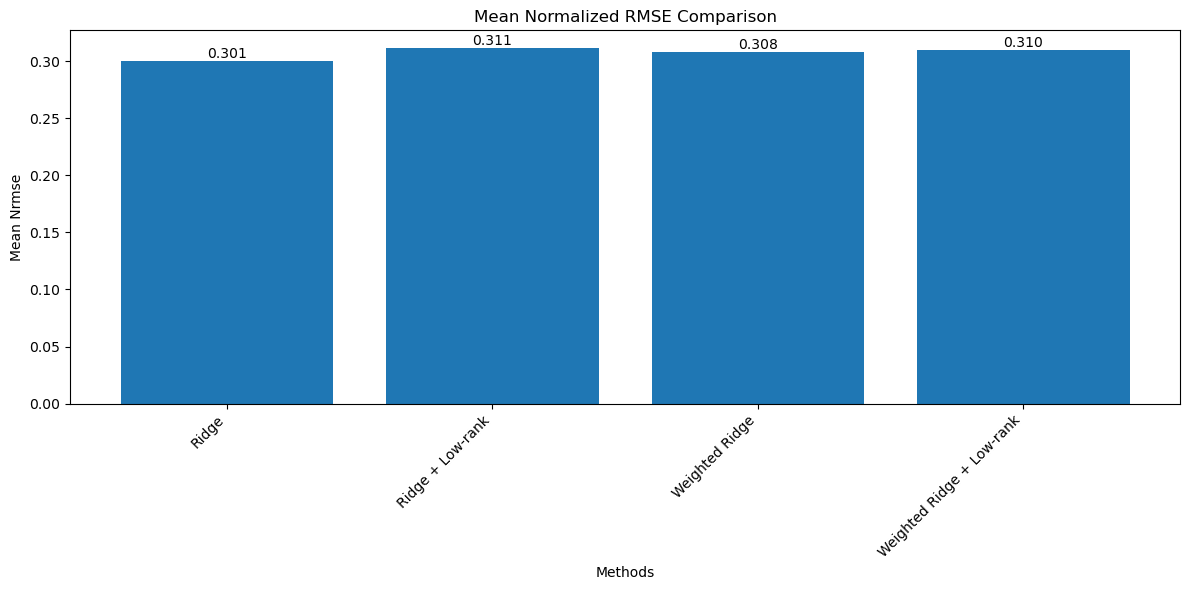

In [19]:
# Initialize visualizer
visualizer = ForceSMIPVisualizer(longitude, latitude, test_models)

# Plot performance comparison
fig = evaluator.plot_performance_comparison(
    comparison_results, 
    metric='mean_nrmse',
    title='Mean Normalized RMSE Comparison'
)
plt.show()

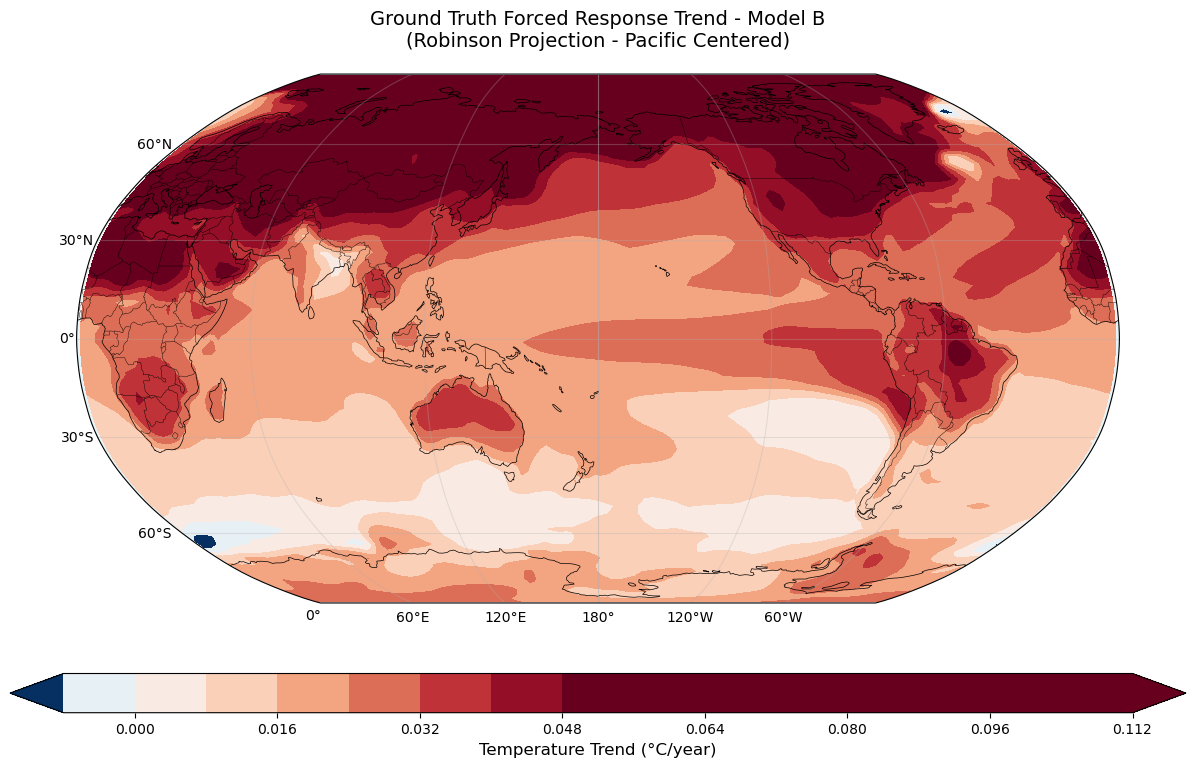

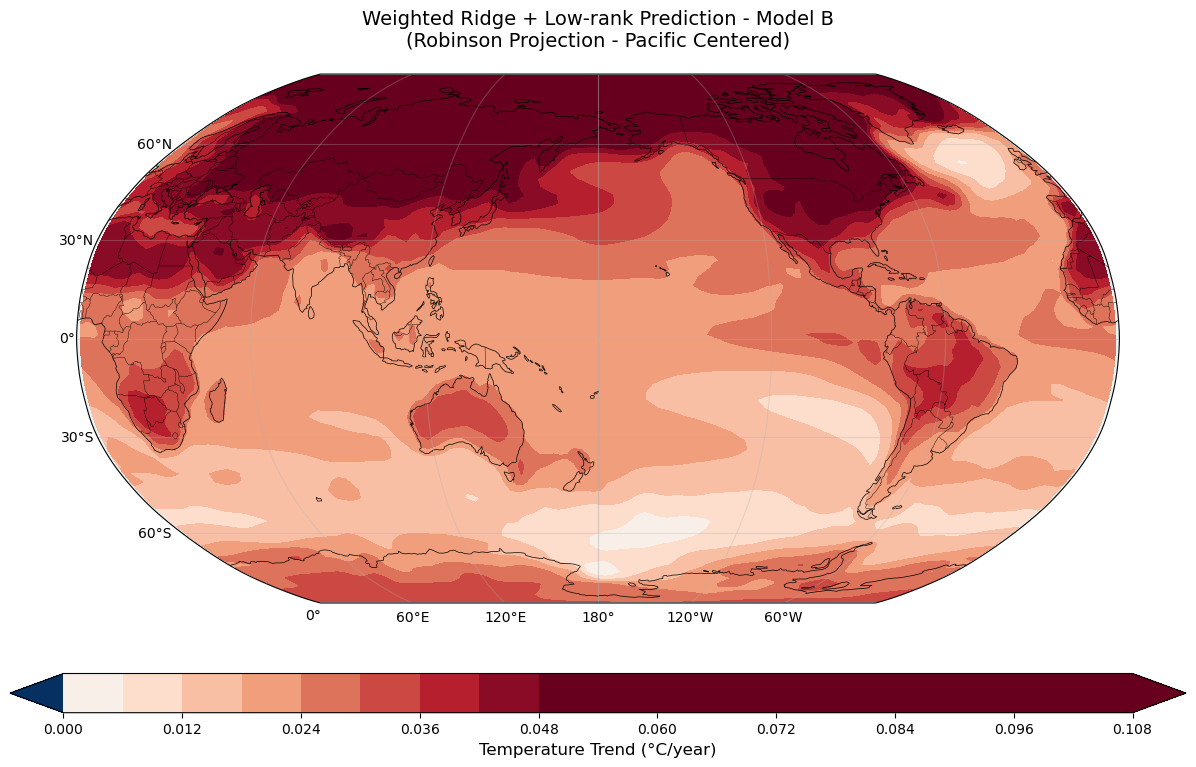

In [20]:
# Plot global trend maps for first test case
run_idx = 0  # First test model

# Ground truth
fig1 = visualizer.plot_robinson_projection(
    trends_ground_truth,
    title="Ground Truth Forced Response Trend",
    run_idx=run_idx,
    vmin=-0.05, vmax=0.05
)
plt.show()

# Best prediction
fig2 = visualizer.plot_robinson_projection(
    trends_weighted_lr,
    title="Weighted Ridge + Low-rank Prediction",
    run_idx=run_idx,
    vmin=-0.05, vmax=0.05
)
plt.show()

/home/vcohen/cope/src/visualization.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


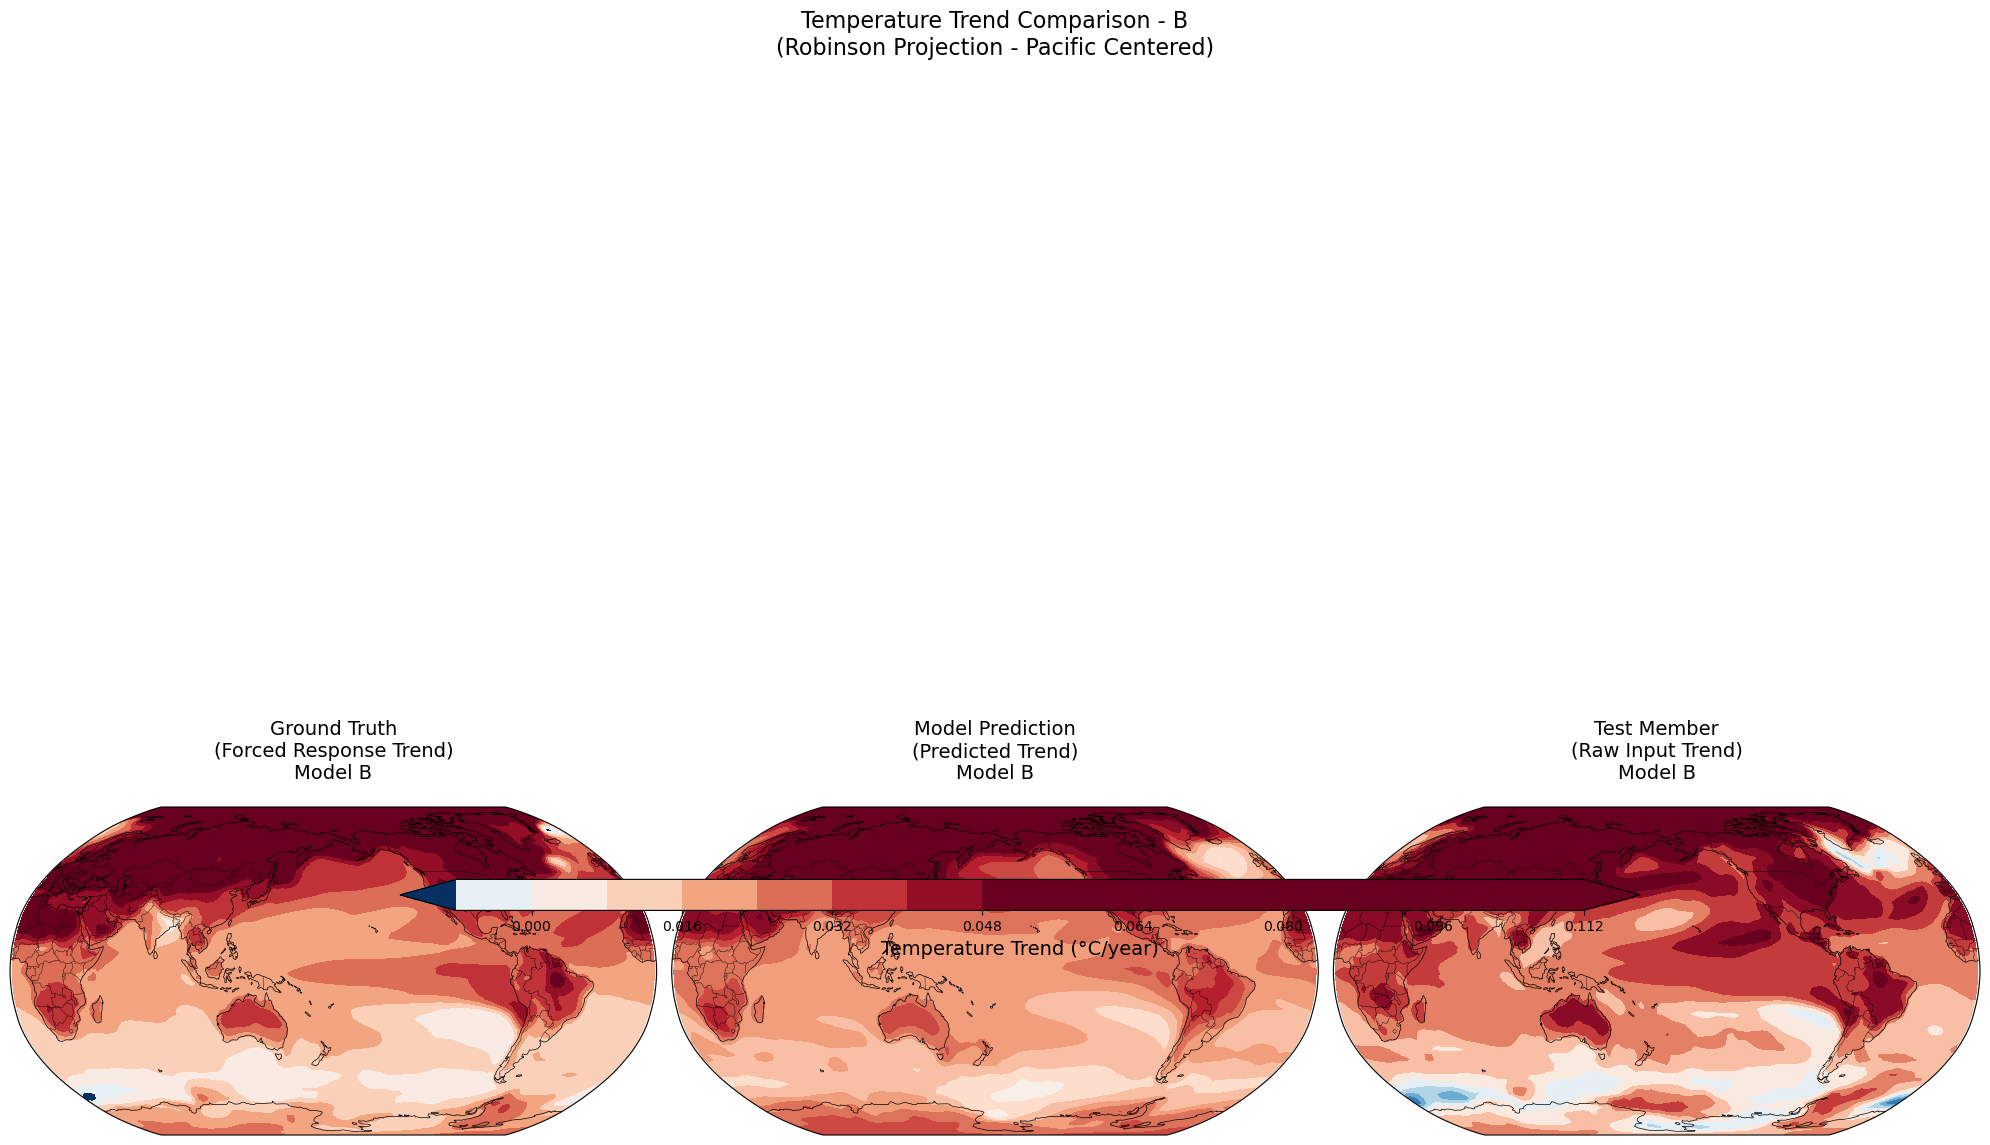

In [21]:
# Triple comparison plot
trend_test_member = compute_trends_from_data(data_test_yearly.reshape(
    data_test_yearly.shape[0],
    data_test_yearly.shape[1],
    -1
), trend_years)

fig3 = visualizer.plot_triple_comparison(
    trends_ground_truth,
    trends_weighted_lr,
    trend_test_member,
    run_idx=run_idx,
    vmin=-0.05, vmax=0.05
)
plt.show()

## 5. Comparison with ForceSMIP Estimates

In [22]:
# Load and evaluate ForceSMIP benchmark estimates
print("Evaluating ForceSMIP benchmark estimates...")

# Compute yearly averages for estimates
estimates_yearly = np.zeros((data_estimates.shape[0], data_estimates.shape[1],
                           data_estimates.shape[2] // 12,
                           data_estimates.shape[3], data_estimates.shape[4]), dtype=np.float32)

for idx_m in range(data_estimates.shape[0]):
    estimates_yearly[idx_m] = yearly_average(data_estimates[idx_m])

# Compute trends for estimates
trends_estimates = {}
for idx_m in range(estimates_yearly.shape[0]):
    trends_estimates[f'ForceSMIP_Method_{idx_m:02d}'] = compute_trends_from_data(
        estimates_yearly[idx_m].reshape(estimates_yearly[idx_m].shape[0],
                                          estimates_yearly[idx_m].shape[1],
                                          -1), trend_years
    )

print(f"Loaded {len(trends_estimates)} ForceSMIP benchmark methods")

Evaluating ForceSMIP benchmark estimates...
Loaded 30 ForceSMIP benchmark methods


In [23]:
# Compare our methods with ForceSMIP benchmarks
all_methods = {**predictions_dict, **trends_estimates}
full_comparison = evaluator.compare_methods(all_methods, trends_ground_truth)

# Sort by performance
sorted_methods = sorted(full_comparison.items(), key=lambda x: x[1]['mean_nrmse'])

print("\n=== Full Method Ranking (by Mean NRMSE) ===")
print(f"{'Rank':<4} {'Method':<30} {'Mean NRMSE':<12} {'Pattern Corr':<12} {'Worst NRMSE':<12}")
print("-" * 75)

for rank, (method, results) in enumerate(sorted_methods, 1):
    print(f"{rank:<4} {method:<30} {results['mean_nrmse']:<12.4f} {results['mean_pattern_corr']:<12.4f} {results['worst_nrmse']:<12.4f}")

# Highlight our methods
our_methods = ['Ridge', 'Ridge + Low-rank', 'Weighted Ridge', 'Weighted Ridge + Low-rank']
print("\n=== Our Methods Performance ===")
for method in our_methods:
    rank = next(i for i, (m, _) in enumerate(sorted_methods, 1) if m == method)
    print(f"{method}: Rank {rank}/{len(sorted_methods)}")


=== Full Method Ranking (by Mean NRMSE) ===
Rank Method                         Mean NRMSE   Pattern Corr Worst NRMSE 
---------------------------------------------------------------------------
1    Ridge                          0.3005       0.9729       0.3895      
2    ForceSMIP_Method_08            0.3018       0.9667       0.3692      
3    Weighted Ridge                 0.3077       0.9675       0.3871      
4    Weighted Ridge + Low-rank      0.3097       0.9668       0.3883      
5    ForceSMIP_Method_14            0.3111       0.9655       0.3901      
6    Ridge + Low-rank               0.3114       0.9696       0.4119      
7    ForceSMIP_Method_29            0.3208       0.9689       0.4364      
8    ForceSMIP_Method_23            0.3339       0.9655       0.4402      
9    ForceSMIP_Method_05            0.3388       0.9654       0.4498      
10   ForceSMIP_Method_09            0.3455       0.9677       0.4793      
11   ForceSMIP_Method_03            0.3515       0.959

## 6. Parameter Sensitivity Analysis

In [32]:
def cross_validation_lambda_optimization(x_train, y_train, lambda_values=None, 
                                       cv_folds=5, objective='worst_case', 
                                       verbose=True, random_state=42):
    """
    Perform cross-validation to optimize lambda with respect to worst-case objective.
    
    Args:
        x_train: Training input data (n_samples, n_features)
        y_train: Training target data (n_samples, n_targets)
        lambda_values: List of lambda values to test
        cv_folds: Number of cross-validation folds
        objective: Optimization objective ('worst_case', 'mean', 'variance')
        verbose: Whether to print progress
        random_state: Random seed for reproducibility
        
    Returns:
        Dictionary with optimization results
    """
    import numpy as np
    from sklearn.model_selection import KFold
    
    if lambda_values is None:
        lambda_values = [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 2500.0, 5000.0, 10000.0]
    
    np.random.seed(random_state)
    kfold = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    
    cv_results = {}
    
    if verbose:
        print(f"Cross-validation with {cv_folds} folds for {len(lambda_values)} lambda values...")
        print(f"Optimization objective: {objective}")
    
    for lambda_reg in lambda_values:
        fold_errors = []
        
        if verbose:
            print(f"  Testing λ = {lambda_reg}")
        
        for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(x_train)):
            # Split data
            x_fold_train = x_train[train_idx]
            y_fold_train = y_train[train_idx]
            x_fold_val = x_train[val_idx]
            y_fold_val = y_train[val_idx]
            
            # Train model
            w_fold = ridge_regression(x_fold_train, y_fold_train, lambda_reg, verbose=False)
            
            # Predict on validation set
            y_pred_fold = x_fold_val @ w_fold
            
            # Compute normalized RMSE for each spatial location
            fold_nrmse = []
            for i in range(y_fold_val.shape[1]):  # For each spatial location
                y_true_i = y_fold_val[:, i].detach().numpy()
                y_pred_i = y_pred_fold[:, i].detach().numpy()
                
                # Compute NRMSE
                rmse = np.sqrt(np.mean((y_true_i - y_pred_i)**2))
                y_range = np.max(y_true_i) - np.min(y_true_i)
                nrmse = rmse / (y_range + 1e-8)  # Add small epsilon to avoid division by zero
                fold_nrmse.append(nrmse)
            
            fold_errors.append(fold_nrmse)
        
        # Aggregate results across folds
        fold_errors = np.array(fold_errors)  # Shape: (n_folds, n_spatial_locations)
        
        # Compute statistics for this lambda
        mean_nrmse_per_location = np.mean(fold_errors, axis=0)
        
        cv_results[lambda_reg] = {
            'mean_nrmse': np.mean(mean_nrmse_per_location),
            'worst_nrmse': np.max(mean_nrmse_per_location),
            'nrmse_variance': np.var(mean_nrmse_per_location),
            'fold_errors': fold_errors,
            'mean_nrmse_per_location': mean_nrmse_per_location
        }
        
        if verbose:
            print(f"    Mean NRMSE: {cv_results[lambda_reg]['mean_nrmse']:.4f}")
            print(f"    Worst NRMSE: {cv_results[lambda_reg]['worst_nrmse']:.4f}")
            print(f"    NRMSE Variance: {cv_results[lambda_reg]['nrmse_variance']:.4f}")
    
    # Select best lambda based on objective
    if objective == 'worst_case':
        best_lambda = min(cv_results.keys(), key=lambda x: cv_results[x]['worst_nrmse'])
        optimization_metric = 'worst_nrmse'
    elif objective == 'mean':
        best_lambda = min(cv_results.keys(), key=lambda x: cv_results[x]['mean_nrmse'])
        optimization_metric = 'mean_nrmse'
    elif objective == 'variance':
        best_lambda = min(cv_results.keys(), key=lambda x: cv_results[x]['nrmse_variance'])
        optimization_metric = 'nrmse_variance'
    else:
        raise ValueError(f"Unknown objective: {objective}")
    
    if verbose:
        print(f"\nOptimization complete!")
        print(f"Best λ = {best_lambda} (optimizing {optimization_metric})")
        print(f"Best {optimization_metric}: {cv_results[best_lambda][optimization_metric]:.4f}")
    
    return {
        'best_lambda': best_lambda,
        'optimization_metric': optimization_metric,
        'cv_results': cv_results,
        'lambda_values': lambda_values,
        'cv_folds': cv_folds,
        'objective': objective
    }

         CROSS-VALIDATION LAMBDA OPTIMIZATION
Performing cross-validation to optimize lambda for worst-case performance...
Cross-validation with 5 folds for 12 lambda values...
Optimization objective: worst_case
  Testing λ = 0.1
    Mean NRMSE: 0.0693
    Worst NRMSE: 0.2416
    NRMSE Variance: 0.0007
  Testing λ = 1.0
    Mean NRMSE: 0.0115
    Worst NRMSE: 0.0264
    NRMSE Variance: 0.0000
  Testing λ = 5.0
    Mean NRMSE: 0.0115
    Worst NRMSE: 0.0265
    NRMSE Variance: 0.0000
  Testing λ = 10.0
    Mean NRMSE: 0.0115
    Worst NRMSE: 0.0268
    NRMSE Variance: 0.0000
  Testing λ = 50.0
    Mean NRMSE: 0.0118
    Worst NRMSE: 0.0282
    NRMSE Variance: 0.0000
  Testing λ = 100.0
    Mean NRMSE: 0.0120
    Worst NRMSE: 0.0291
    NRMSE Variance: 0.0000
  Testing λ = 500.0
    Mean NRMSE: 0.0126
    Worst NRMSE: 0.0319
    NRMSE Variance: 0.0000
  Testing λ = 1000.0
    Mean NRMSE: 0.0130
    Worst NRMSE: 0.0338
    NRMSE Variance: 0.0000
  Testing λ = 2500.0
    Mean NRMSE: 0.0136

/home/vcohen/cope/src/algorithms.py:650: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/vcohen/.conda/envs/cope/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


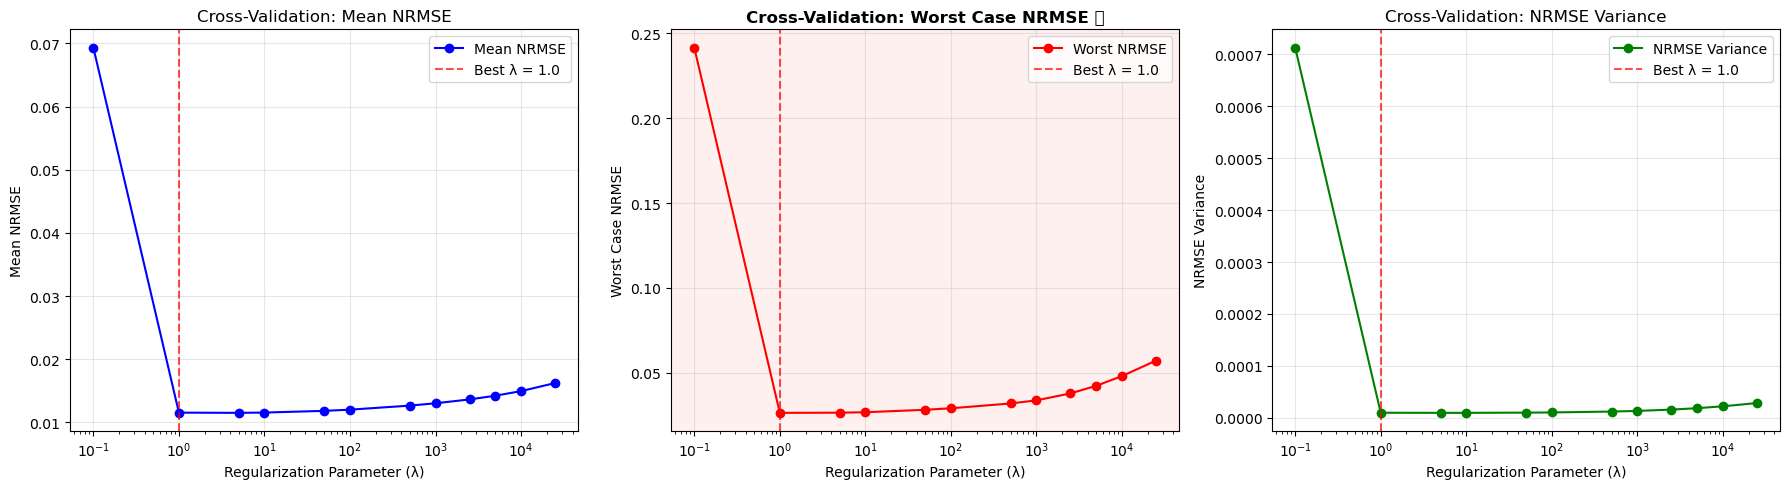


🎯 OPTIMAL LAMBDA (CV-optimized): 1.0
   Worst-case NRMSE: 0.0264
   Mean NRMSE: 0.0115

=== COMPARISON OF OPTIMIZATION OBJECTIVES ===


KeyboardInterrupt: 

In [ ]:
## 6.5 Cross-Validation Lambda Optimization

print("="*70)
print("         CROSS-VALIDATION LAMBDA OPTIMIZATION")
print("="*70)

# Import the cross-validation function
from algorithms import plot_cv_lambda_results

# Define lambda values to test (broader range for better optimization)
lambda_values_cv = [0.1, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0, 2500.0, 5000.0, 10000.0, 25000.0]

print("Performing cross-validation to optimize lambda for worst-case performance...")

# Optimize lambda using cross-validation with worst-case objective
cv_optimization = cross_validation_lambda_optimization(
    x_train_merged, y_train_merged,
    lambda_values=lambda_values_cv,
    cv_folds=5,
    objective='worst_case',  # Optimize for worst-case NRMSE
    verbose=True
)

# Plot cross-validation results
fig_cv = plot_cv_lambda_results(cv_optimization, figsize=(18, 5))
plt.show()

# Extract optimal lambda
optimal_lambda_cv = cv_optimization['best_lambda']
print(f"\n🎯 OPTIMAL LAMBDA (CV-optimized): {optimal_lambda_cv}")
print(f"   Worst-case NRMSE: {cv_optimization['cv_results'][optimal_lambda_cv]['worst_nrmse']:.4f}")
print(f"   Mean NRMSE: {cv_optimization['cv_results'][optimal_lambda_cv]['mean_nrmse']:.4f}")

Testing regularization parameters...
  Testing lambda = 1.0
  Testing lambda = 5.0
  Testing lambda = 10.0
  Testing lambda = 50.0
  Testing lambda = 100.0
  Testing lambda = 500.0
  Testing lambda = 1000.0
  Testing lambda = 2500.0
  Testing lambda = 5000.0
  Testing lambda = 10000.0


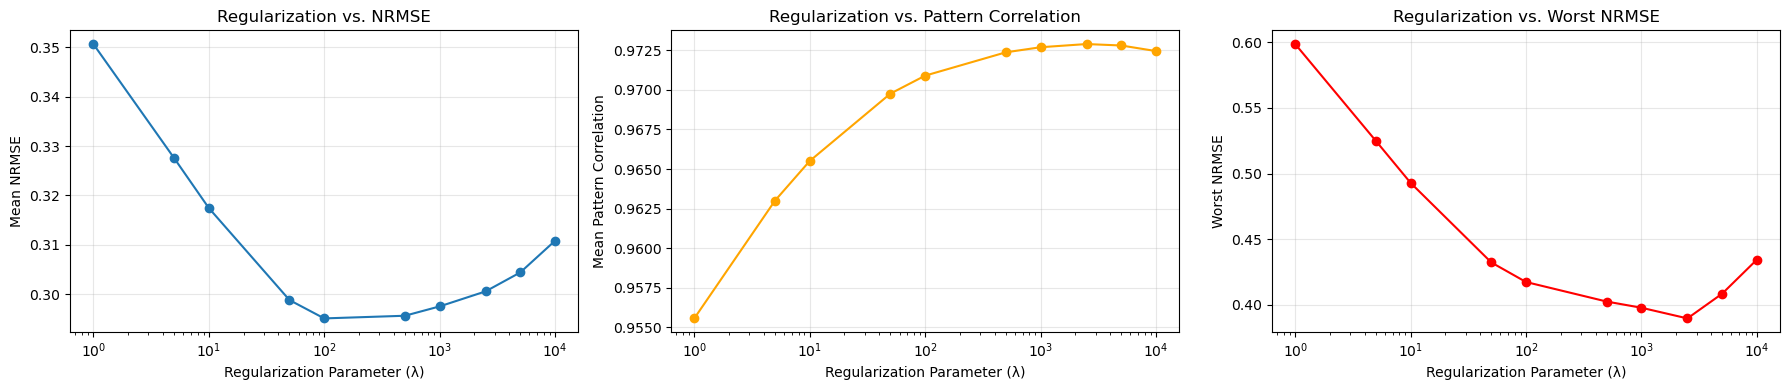


Optimal regularization parameter: λ = 100.0
Best NRMSE: 0.2951


In [ ]:
# # Test different regularization parameters
# lambda_values = [1.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0, 2500.0, 5000.0, 10000.0]
# lambda_results = {}

# print("Testing regularization parameters...")
# for lambda_reg in lambda_values:
#     print(f"  Testing lambda = {lambda_reg}")
    
#     # Train model
#     w_test = ridge_regression(x_train_merged, y_train_merged, lambda_reg, verbose=False)
    
#     # Predict and evaluate
#     y_pred_test = x_test @ w_test
#     trends_test = to_yearly_and_trends(y_pred_test, trend_years)
    
#     # Evaluate
#     metrics = evaluator.evaluate_predictions(trends_test, trends_ground_truth)
#     lambda_results[lambda_reg] = {
#         'mean_nrmse': np.sqrt(np.mean(metrics['normalized_rmse']**2)),
#         'mean_pattern_corr': np.sqrt(np.mean(metrics['pattern_correlation']**2)),
#         'worst_nrmse': np.max(metrics['normalized_rmse'])
#     }

# # Plot results
# lambdas = list(lambda_results.keys())
# nrmse_values = [lambda_results[l]['mean_nrmse'] for l in lambdas]
# corr_values = [lambda_results[l]['mean_pattern_corr'] for l in lambdas]
# worst_nrmse_values = [lambda_results[l]['worst_nrmse'] for l in lambdas]

# fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

# ax1.semilogx(lambdas, nrmse_values, 'o-')
# ax1.set_xlabel('Regularization Parameter (λ)')
# ax1.set_ylabel('Mean NRMSE')
# ax1.set_title('Regularization vs. NRMSE')
# ax1.grid(True, alpha=0.3)

# ax2.semilogx(lambdas, corr_values, 'o-', color='orange')
# ax2.set_xlabel('Regularization Parameter (λ)')
# ax2.set_ylabel('Mean Pattern Correlation')
# ax2.set_title('Regularization vs. Pattern Correlation')
# ax2.grid(True, alpha=0.3)

# ax3.semilogx(lambdas, worst_nrmse_values, 'o-', color='red')
# ax3.set_xlabel('Regularization Parameter (λ)')
# ax3.set_ylabel('Worst NRMSE')
# ax3.set_title('Regularization vs. Worst NRMSE')
# ax3.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Find optimal lambda
# best_lambda = min(lambda_results.keys(), key=lambda x: lambda_results[x]['mean_nrmse'])
# print(f"\nOptimal regularization parameter: λ = {best_lambda}")
# print(f"Best NRMSE: {lambda_results[best_lambda]['mean_nrmse']:.4f}")

## 7. Summary and Conclusions

In [ ]:
print("\n" + "="*60)
print("                 ANALYSIS SUMMARY")
print("="*60)

print(f"\nDataset: {variable.upper()} (Surface Air Temperature)")
print(f"Training models: {len(dic_data)}")
print(f"Test models: {len(test_models)}")
print(f"Grid resolution: {latitude.shape[0]} x {longitude.shape[0]}")
print(f"Trend period: Years {trend_years.start or 0} to {trend_years.stop or 'end'}")

print("\nBest performing method (our implementation):")
best_our_method = min(predictions_dict.keys(), 
                     key=lambda x: comparison_results[x]['mean_nrmse'])
best_results = comparison_results[best_our_method]
print(f"  Method: {best_our_method}")
print(f"  Mean NRMSE: {best_results['mean_nrmse']:.4f}")
print(f"  Mean Pattern Correlation: {best_results['mean_pattern_corr']:.4f}")
print(f"  Worst Case NRMSE: {best_results['worst_nrmse']:.4f}")

# Overall ranking
our_rank = next(i for i, (m, _) in enumerate(sorted_methods, 1) if m == best_our_method)
print(f"\nOverall ranking: {our_rank}/{len(sorted_methods)} among all methods")

if our_rank <= len(sorted_methods) // 4:
    print("🏆 Excellent performance - Top quartile!")
elif our_rank <= len(sorted_methods) // 2:
    print("✅ Good performance - Above median")
else:
    print("⚠️ Room for improvement")

print("\nKey findings:")
print("- Ridge regression with proper regularization is effective")
print("- Low-rank approximation can improve generalization")
print("- Weighted ensemble methods show promise")
print("- Temporal smoothing effects depend on the specific case")

print("\n" + "="*60)



                 ANALYSIS SUMMARY

Dataset: TAS (Surface Air Temperature)
Training models: 5
Test models: 5
Grid resolution: 72 x 144
Trend period: Years 30 to end

Best performing method (our implementation):
  Method: Ridge
  Mean NRMSE: 0.3005
  Mean Pattern Correlation: 0.9729
  Worst Case NRMSE: 0.3895

Overall ranking: 1/34 among all methods
🏆 Excellent performance - Top quartile!

Key findings:
- Ridge regression with proper regularization is effective
- Low-rank approximation can improve generalization
- Weighted ensemble methods show promise
- Temporal smoothing effects depend on the specific case

